<a href="https://colab.research.google.com/github/danielsovres/Aulas/blob/main/ML%20-%20Gradient%20Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 07 - Boosting II: Gradient Boosting

___
### Recordando: Bagging vs Boosting

Até o momento, mencionamos alguns métodos de ensemble - *bagging* e *boosting* -, e contrastamos algumas diferenças entre eles, conforme esquematizado na figura abaixo.

<img src=https://pluralsight2.imgix.net/guides/81232a78-2e99-4ccc-ba8e-8cd873625fdf_2.jpg width=600>

Nesta aula, vamos avaliar uma outra metodologia de ensemble: o **gradient boosting**.

___
## Um outro método de ensemble: Gradient boosting

Além dos métodos que estudamos, há ainda outras classes de métodos de ensemble. Em particular, vamos agora estudar a classe de modelos que utiliza do procedimento conhecido como **gradient boosting**.

O gradient boosting também é baseado no princípio de boosting (utilização de weak learners sequencialmente adicionados de modo a **sequencialmente minimizar os erros cometidos**).

<img src=https://miro.medium.com/max/788/1*pEu2LNmxf9ttXHIALPcEBw.png width=600>

Entretanto, este método implementa o boosting através de um **gradiente** explícito. Isso significa que, a partir da definição de uma **função perda/erro**, que geralmente objetivamos minimizar, utilizaremos o *gradiente* da função em um dado ponto como indicativo de melhora/piora do modelo: quanto mais caminharmos na direção que o gradiente indique que estamos **diminuindo o erro mensurado pela função**, mais próximos estaremos de **convergir para um erro mínimo** conforme ditado pela nossa função de erro.

Ou seja, em suma, a ideia é que caminhemos na direção do **erro mínimo** de maneira iterativa **passo a passo**, sendo que este caminho se dá justamente pelo **gradiente** da **função de custo/perda**, que mede justamente os erros cometidos.

<img src = https://miro.medium.com/v2/resize:fit:4800/format:webp/1*HrFZV7pKPcc5dzLaWvngtQ.png width = 400>:

<img src=https://upload.wikimedia.org/wikipedia/commons/a/a3/Gradient_descent.gif width=400>

Este método é conhecido como:

### Gradiente descendente

O objetivo geral do método é bem direto: determinar quais são os **parâmetros** da hipótese que minimizam a função de custo/perda. Para isso, o método "percorre" a função de erro, indo em direção ao seu mínim, e este "caminho" feito na função se dá justamente pela **determinação iterativa dos parâmetros**, isto é, **a cada passo, chegamos mais perto dos parâmetros finais da hipótese**, conforme eles são ajustados aos dados.

- Uma **função de custo/perda (loss)** é explicitamente minimizada por um procedimento de gradiente;

- O gradiente está relacionado com o procedimento de **encadeamento progressivo entre weak learners**, seguindo a ideia do boosting.

___
### Gradient boosting no sklearn

As classes do sklearn são:

- [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)

- [GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html#sklearn.ensemble.GradientBoostingRegressor)

E os principais hiperparâmetros a serem ajustados são:

- `n_estimators` : novamente, o número de weak learners encadeados.

- `learning_rate` : a constante que multiplica o gradiente no gradiente descendente. Essencialmente, controla o "tamanho do passo" a ser dado em direção ao mínimo.

Segundo o próprio [User Guide](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting): "*Empirical evidence suggests that small values of `learning_rate` favor better test error. The lireature recommends to set the learning rate to a small constant (e.g. `learning_rate <= 0.1`) and choose `n_estimators` by early stopping.*"

Ainda sobre a learning rate, as ilustrações a seguir ajudam a entender sua importância:

<img src=https://www.jeremyjordan.me/content/images/2018/02/Screen-Shot-2018-02-24-at-11.47.09-AM.png width=700>

<img src=https://cdn-images-1.medium.com/max/1440/0*A351v9EkS6Ps2zIg.gif width=500>

___

### Gradient Boosting na prática

Vamos retomar o exemplo da [base de dados de crédito](https://www.kaggle.com/datasets/uciml/german-credit), para efeitos de comparação com o que já fizemos; mas, agora, modelando a partir do **gradient boosting**.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import GradientBoostingClassifier #importar a função
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("datasets/german_credit_data.csv", index_col=0)

In [ ]:
X = df.drop(columns="Risk") #features
y = df["Risk"] #target
features_num = X.select_dtypes(include=np.number).columns.tolist() #seleciona apenas números
X = X[features_num] #transforma Features X em apenas numéricos

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


scaler = StandardScaler()
X_train[features_num] = scaler.fit_transform(X_train[features_num]) #fita e transforma X_train
X_test[features_num] = scaler.transform(X_test[features_num]) #transforma X_test

In [ ]:
gboost = GradientBoostingClassifier()
gboost.fit(X_train, y_train) #fitar os dados de treino de X e y na função desejada (gboost)

GradientBoostingClassifier()

In [ ]:
y_pred_train = gboost.predict(X_train) #fazer o predict X_train
y_pred_test = gboost.predict(X_test) #fazer o predict X_test

In [ ]:
#OBS: O PREDICT DE X_train vira y_pred_train
# E o de X_test vira y_pred_test

# Comentário da inteligência artificial

Explicação da teoria entre o **fit**, **transform** e os **predicts**:

**1. Identificar Overfitting (O "Efeito Decorba")**

O objetivo de qualquer modelo de Machine Learning é **generalizar**, ou seja, aprender padrões que funcionem para dados que ele nunca viu.

`predict(X_train)`: Mostra o quão bem o modelo aprendeu o padrão dos dados. Se o erro aqui for quase zero, o modelo pode ter apenas "decorado" os exemplos (overfitting).

`predict(X_test)`: Mostra como o modelo se comporta no mundo real.


**A lógica da comparação:**
* Treino bom + Teste bom: Modelo equilibrado.   
* Treino excelente + Teste ruim: Overfitting.      
O modelo foca em ruídos do treino e falha na prática.
* Treino ruim + Teste ruim: Underfitting.   
O modelo é simples demais para o problema.   

**2. Validar a Performance**
O comando `fit` apenas calibra os parâmetros internos (os pesos do Gradient Boosting). Ele não te devolve uma nota de 0 a 10 automaticamente.

Para calcular métricas como Acurácia, RMSE ou F1-Score, você precisa comparar o que o modelo acha que é o resultado (`y_pred`) com o que o resultado realmente é (`y_test` ou `y_train`).

**Passo - Ação - Objetivo **
* **Fit** - Estudar o livro - Ajustar os parâmetros internos.
* **Predict** - Fazer a prova - Gerar as previsões para serem avaliadas.
* **Score/Metrics** - Corrigir a prova - Calcular a margem de erro.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

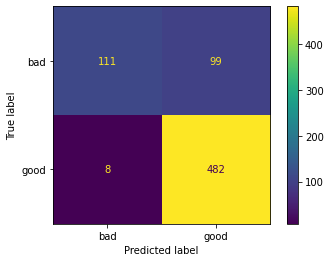

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train) #matriz de confusão de treino - comparo a predição de X_train com o y_train

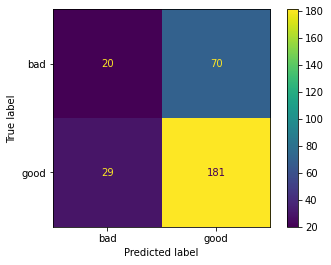

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test) #matriz de confusão de teste - comparo a predição de X_test com o y_pred_test

In [ ]:
print(classification_report(y_pred_test, y_test)) #report de classificação
# Predição de X_train vira y_pred_test ---- Compara com y_test

#Resultados - a precisão está muito ruim

              precision    recall  f1-score   support

         bad       0.22      0.41      0.29        49
        good       0.86      0.72      0.79       251

    accuracy                           0.67       300
   macro avg       0.54      0.56      0.54       300
weighted avg       0.76      0.67      0.70       300



**Vamos alterar alguns hiperparâmetros:
learning_rate = 0.1 -> 1**

              precision    recall  f1-score   support

         bad       0.34      0.42      0.38        74
        good       0.80      0.74      0.77       226

    accuracy                           0.66       300
   macro avg       0.57      0.58      0.57       300
weighted avg       0.68      0.66      0.67       300



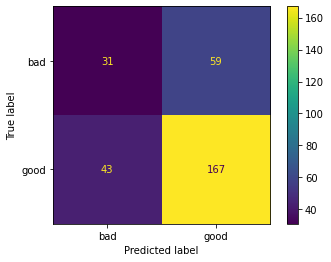

In [ ]:
gboost = GradientBoostingClassifier(random_state = 42,
                                   n_estimators = 100,
                                   learning_rate = 1)
#crio um novo gboost - só que com o Learning Rate (taxa de aprendizado) MUITO maior

gboost.fit(X_train, y_train) #fito o treino
y_pred_test = gboost.predict(X_test) #faço predição dos dados de treino de X
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test) #Faço a matriz de confusão
print(classification_report(y_pred_test, y_test)) #faço o relatório de classificação

In [ ]:
#Resultado - Aumentando a taxa de aprendizado, os resultados foram bem melhores
#Pelo menos na precisão do bad

Vamos alterar alguns hiperparâmetros:
learning_rate = 0.1 -> 0.01

              precision    recall  f1-score   support

         bad       0.08      0.64      0.14        11
        good       0.98      0.71      0.83       289

    accuracy                           0.71       300
   macro avg       0.53      0.67      0.48       300
weighted avg       0.95      0.71      0.80       300



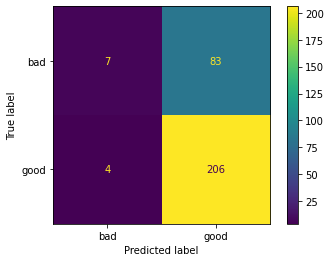

In [ ]:
gboost = GradientBoostingClassifier(random_state = 42,n_estimators = 100,learning_rate = 0.01)
gboost.fit(X_train, y_train)
y_pred_test = gboost.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
print(classification_report(y_pred_test, y_test))

Como temos recorrentemente notado, a escolha dos hiperparâmetros pode influir fortemente sobre os resultados. Sendo assim, é sempre uma boa prática ter a possibilidade de otimização de hiperparâmetros sob consideração.
___